In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

df = pd.read_csv('data/creditcard.csv')

In [48]:
df.head()
df['Time'].value_counts

<bound method IndexOpsMixin.value_counts of 0              0.0
1              0.0
2              1.0
3              1.0
4              2.0
            ...   
284802    172786.0
284803    172787.0
284804    172788.0
284805    172788.0
284806    172792.0
Name: Time, Length: 284807, dtype: float64>

In [49]:
df['Hour'] = (df['Time'] // 3600) % 24

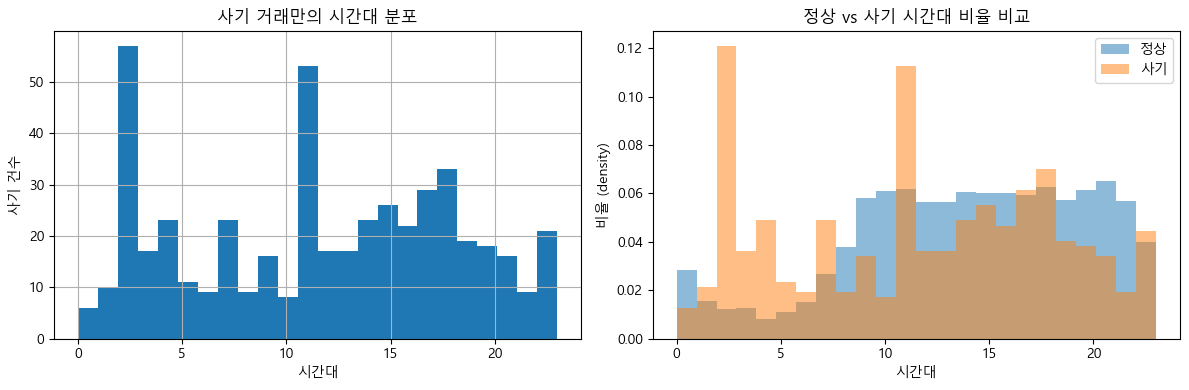

Hour
0.0      6
1.0     10
2.0     57
3.0     17
4.0     23
5.0     11
6.0      9
7.0     23
8.0      9
9.0     16
10.0     8
11.0    53
12.0    17
13.0    17
14.0    23
15.0    26
16.0    22
17.0    29
18.0    33
19.0    19
20.0    18
21.0    16
22.0     9
23.0    21
Name: count, dtype: int64


In [50]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# 사기 거래만 필터링해서 시간대 분포 확인
fraud = df[df['Class'] == 1]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
fraud['Hour'].hist(bins=24)
plt.xlabel('시간대')
plt.ylabel('사기 건수')
plt.title('사기 거래만의 시간대 분포')

plt.subplot(1, 2, 2)
normal = df[df['Class'] == 0]
plt.hist(normal['Hour'], bins=24, alpha=0.5, label='정상', density=True)
plt.hist(fraud['Hour'], bins=24, alpha=0.5, label='사기', density=True)
plt.xlabel('시간대')
plt.ylabel('비율 (density)')
plt.title('정상 vs 사기 시간대 비율 비교')
plt.legend()
plt.tight_layout()
plt.show()

print(fraud['Hour'].value_counts().sort_index())

In [51]:
shape = df.shape
print(shape)
print(df.isnull().sum().sum())
print(df['Class'].value_counts())
print(df['Class'].mean()*100)

(284807, 32)
0
Class
0    284315
1       492
Name: count, dtype: int64
0.1727485630620034


In [52]:
# 전처리 + 모델 학습
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

df['Hour'] = (df['Time'] // 3600) % 24
df = df.drop(['Time'], axis=1)

# Amount 정규화 (V1~V28은 이미 PCA처리됨)
df['Amount_scaled'] = StandardScaler().fit_transform(df[['Amount']])
df = df.drop(['Amount'], axis=1)

x = df.drop('Class', axis=1)
y = df['Class']

# train/test 분리 (stratify 필수)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

print(f"학습 데이터 사기 건수: {y_train.sum()}")
print(f"테스트 데이터 사기 건수: {y_test.sum()}")
print(f"피처 수: {x.shape[1]}개")

학습 데이터 사기 건수: 394
테스트 데이터 사기 건수: 98
피처 수: 30개


In [56]:
# 모델 학습 + 평가
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

models = {
    'logistic' : LogisticRegression(max_iter=1000, random_state=42),
    'random_f' : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'  : XGBClassifier(
                    scale_pos_weight=len(y[y==0])/len(y[y==1]),
                    eval_metric='logloss',
                    random_state=42)
}
for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    prob = model.predict_proba(x_test)[:, 1]

    print(f"\n{'='*45}")
    print(f"[{name}]")
    print(classification_report(y_test, pred, target_names=['정상', '사기']))
    print(f"ROC-AUC: {roc_auc_score(y_test, prob):.3f}")



[logistic]
              precision    recall  f1-score   support

          정상       1.00      1.00      1.00     56864
          사기       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.954

[random_f]
              precision    recall  f1-score   support

          정상       1.00      1.00      1.00     56864
          사기       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.958

[XGBoost]
              precision    recall  f1-score   support

          정상       1.00      1.00      1.00     56864
          사기       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted 

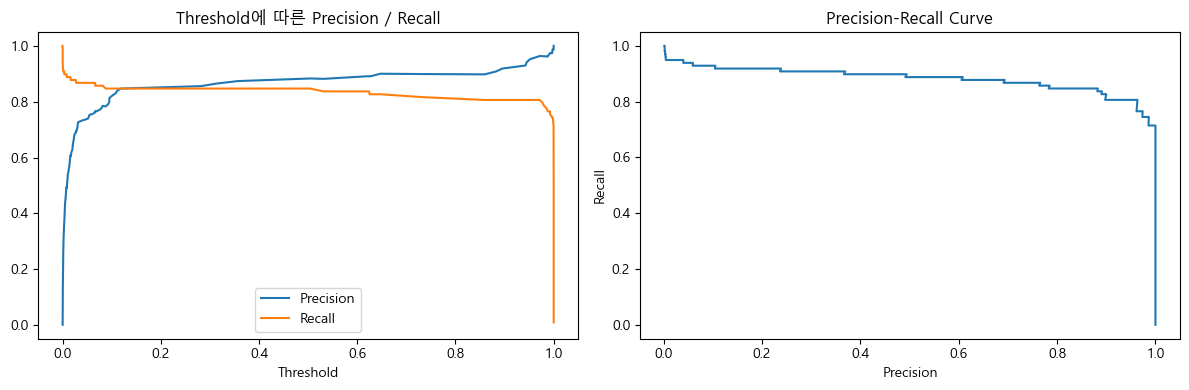


[XGBoost threshold=0.3]
              precision    recall  f1-score   support

          정상       1.00      1.00      1.00     56864
          사기       0.86      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [67]:
# threshold 조정으로 Recall 올리기
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

prob_xgb = models['XGBoost'].predict_proba(x_test)[:, 1]

# threshold별 precision/recall 변화
precisions, recalls, thresholds = precision_recall_curve(y_test, prob_xgb)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.title('Threshold에 따른 Precision / Recall')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(precisions, recalls)
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

# ✅ threshold 0.3으로 낮춰서 예측
pred_low = (prob_xgb >= 0.3).astype(int)
print("\n[XGBoost threshold=0.3]")
print(classification_report(y_test, pred_low, target_names=['정상', '사기']))

In [71]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import recall_score

# SMOTE 적용 전 분포
print(f"SMOTE 전 - 정상: {sum(y_train==0)}, 사기: {sum(y_train==1)}")

smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

print(f"SMOTE 후 - 정상: {sum(y_train_sm==0)}, 사기: {sum(y_train_sm==1)}")

xgb_smote = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    eval_metric='logloss',
    random_state=42
)
xgb_smote.fit(x_train_sm, y_train_sm)

pred_smote = xgb_smote.predict(x_test)
prob_smote = xgb_smote.predict_proba(x_test)[:, 1]

print("\n[XGBoost + SMOTE]")
print(classification_report(y_test, pred_smote, target_names=['정상', '사기']))
print(f"ROC-AUC: {roc_auc_score(y_test, prob_smote):.3f}")

print("\n=== 비교 ===")
print(f"기존 XGBoost  Recall: 0.85")
print(f"SMOTE XGBoost Recall: {recall_score(y_test, pred_smote):.2f}")

SMOTE 전 - 정상: 227451, 사기: 394
SMOTE 후 - 정상: 227451, 사기: 227451

[XGBoost + SMOTE]
              precision    recall  f1-score   support

          정상       1.00      1.00      1.00     56864
          사기       0.53      0.86      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.93      0.83     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.977

=== 비교 ===
기존 XGBoost  Recall: 0.85
SMOTE XGBoost Recall: 0.86


In [73]:
from sklearn.metrics import recall_score, precision_score

prob_xgb = models['XGBoost'].predict_proba(x_test)[:, 1]

print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 40)
for t in [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]:
    pred_t = (prob_xgb >= t).astype(int)
    r = recall_score(y_test, pred_t)
    p = precision_score(y_test, pred_t)
    f1 = 2 * (p * r) / (p + r)
    print(f"{t:>10}  {r:>8.3f}  {p:>10.3f}  {f1:>8.3f}")

 Threshold   Recall  Precision       F1
----------------------------------------
       0.5     0.847       0.883     0.865
       0.4     0.847       0.883     0.865
       0.3     0.847       0.865     0.856
       0.2     0.847       0.856     0.851
       0.1     0.847       0.822     0.834
      0.05     0.867       0.739     0.798
